## *Baseline Modelling*
---
Models that I plan to use:
: 1. Logistic Regression
2. Naive Bayes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/processed/WELFake_processed.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (62704, 14)


,Unnamed: 0,title,text,label,full_text,clean_text,tokens,processed_text,word_count,char_count,sentence_count,url_count,exclamation_count,question_count
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,"['law', 'enforcement', 'high', 'alert', 'follo...",law enforcement high alert following threat co...,889,5180,63,0,2,7
1,1,NaN,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?,did they post their votes for hillary already,"['post', 'vote', 'hillary', 'already']",post vote hillary already,8,46,1,0,0,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last n...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says mos...,"['unbelievable', 'obama’s', 'attorney', 'gener...",unbelievable obama’s attorney general say char...,52,353,2,0,1,0
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story of christ...,"['bobby', 'jindal', 'raised', 'hindu', 'us', '...",bobby jindal raised hindu us story christian c...,1337,8116,61,0,0,1
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis an image of its terrifyin...,"['satan', 'russia', 'unvelis', 'image', 'terri...",satan russia unvelis image terrifying new ‘sup...,345,2012,11,0,0,0


### Selecting my text and labels and split my train/test data

In [3]:
X = df["processed_text"]
y = df["label"]

print("Number of articles:", len(X))
print("Number of labels:", len(y))

Number of articles: 62704
Number of labels: 62704


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 50163
Testing samples: 12541


### Tokenization 

In [6]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (50163, 50000)
Testing TF-IDF shape: (12541, 50000)


#### Logistic Regression

In [7]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

y_pred_lr = logistic_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Fake", "Real"]
))

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

              precision    recall  f1-score   support

        Fake       0.95      0.96      0.96      6924
        Real       0.95      0.94      0.95      5617

    accuracy                           0.95     12541
   macro avg       0.95      0.95      0.95     12541
weighted avg       0.95      0.95      0.95     12541

Accuracy:  0.9549
Precision: 0.9550
Recall:    0.9439
F1 Score:  0.9494


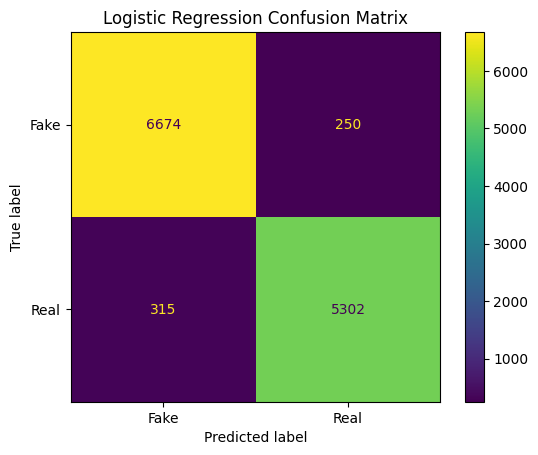

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### Naive Bayes

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Fake", "Real"]
))

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1 Score:  {nb_f1:.4f}")

              precision    recall  f1-score   support

        Fake       0.90      0.88      0.89      6924
        Real       0.86      0.88      0.87      5617

    accuracy                           0.88     12541
   macro avg       0.88      0.88      0.88     12541
weighted avg       0.88      0.88      0.88     12541

Accuracy:  0.8821
Precision: 0.8607
Recall:    0.8791
F1 Score:  0.8698


#### **Model Comparison**

In [10]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall
    ],
    "F1 Score": [
        lr_f1,
        nb_f1
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.954948,0.954971,0.943920,0.949414
1,Naive Bayes,0.882147,0.860729,0.879117,0.869826


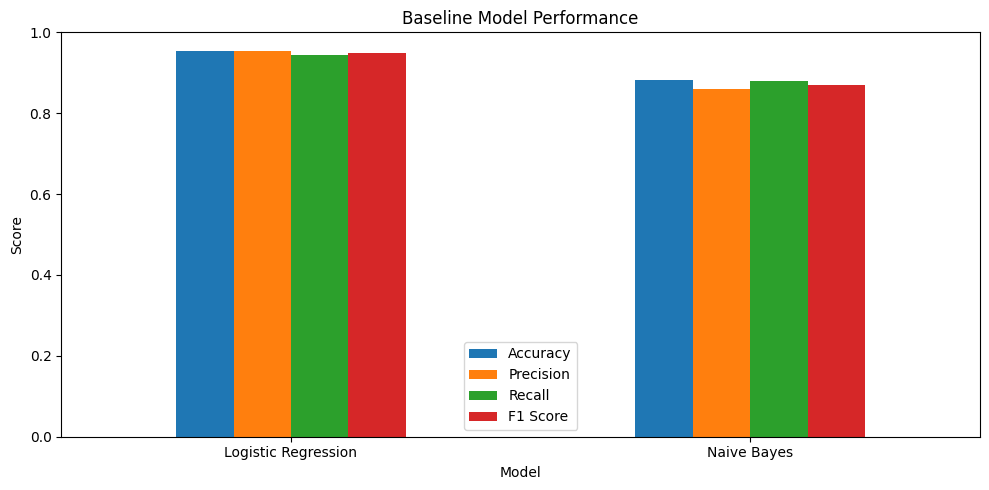

In [11]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Baseline Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# finding the most influential words

feature_names = tfidf.get_feature_names_out()
coefficients = logistic_model.coef_[0]

top_positive = coefficients.argsort()[-20:][::-1]
top_negative = coefficients.argsort()[:20]

print("Words associated with label 1 (Real):")

for i in top_positive:
    print(feature_names[i], round(coefficients[i], 3))

print("\nWords associated with label 0 (Fake):")

for i in top_negative:
    print(feature_names[i], round(coefficients[i], 3))

Words associated with label 1 (Real):
via 13.033
image 10.687
url 7.952
video 7.673
image via 7.496
hillary 7.463
october 7.459
november 5.466
breaking 4.566
obama 4.066
fbi 3.682
share 3.421
know 3.307
watch 3.293
wire 3.287
entire 3.131
yearold 3.095
today 3.056
fact 3.042
source 3.027

Words associated with label 0 (Fake):
reuters -22.469
said -17.112
breitbart -11.696
washington reuters -8.416
president donald -7.363
follow -6.665
twitter -6.66
it -6.469
mr -6.144
the -5.683
he -5.574
thursday -5.327
tuesday -5.259
friday -5.172
monday -5.12
york time -5.104
we -4.997
wednesday -4.721
new york -4.431
com -4.363
